In [ ]:
# Imports



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
import sys, os, gc, math, textwrap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

# Load CSV from Drive
df = pd.read_csv('/content/drive/MyDrive/rees46_customer_model.csv')

Mounted at /content/drive


In [ ]:
df.head(10)

,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,...,purchase_latent_factor14,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,target_revenue,target_customer_value,time_step,target_customer_value_lag1,target_actual_profit
0,31,522576412,10133.678750,2019.3250,241.650000,8.400000,16.875000,33.825000,4.225000,0.300000,...,0.633005,0.063525,0.000000,0.000000,0,3403.83,171.760358,0,90.148425,-13.279611
1,53,551695186,5.359195,2019.3620,222.051730,7.827586,14.655172,31.448277,4.034483,0.258621,...,0.395069,0.267275,0.000000,0.000000,1,0.00,387.102758,0,445.168171,3.592337
2,65,561472000,4.885714,2019.0000,297.542850,10.114285,21.000000,43.142857,2.942857,0.285714,...,0.000000,0.000000,0.000000,0.000000,1,0.00,347.097991,0,399.162689,3.216008
3,85,585643355,4175.082759,2019.8966,106.000000,3.931035,17.655172,15.896552,3.655172,0.206897,...,0.165644,0.000000,0.165603,0.263806,0,937.86,279.270244,0,321.607950,-13.185855
4,133,520792937,3.325601,2019.3196,212.865980,7.556701,13.711340,30.989690,3.958763,0.350515,...,0.000000,0.000000,0.048937,0.000000,1,0.00,91.360471,0,105.064542,0.732248
5,137,521945981,5.397887,2019.9436,52.535210,2.323944,12.338028,8.211267,4.014084,0.323944,...,0.000000,0.698178,0.029280,0.000000,1,0.00,139.244402,0,160.131062,1.187650
6,148,537640679,2.509119,2019.1887,258.716980,8.981132,16.415094,37.660378,3.886792,0.264151,...,0.000000,0.000000,0.947968,0.000000,1,0.00,339.181627,0,390.058871,3.223939
7,243,517362083,1741.806604,2019.5409,176.855350,6.308176,15.572327,25.610064,3.691824,0.308176,...,0.000000,0.027968,0.000000,0.000000,0,546.68,128.921606,0,138.427693,-13.254251
8,251,519699976,13389.694569,2019.9214,48.539326,2.224719,11.337079,6.494382,3.955056,0.269663,...,0.000000,0.000000,0.000000,0.000000,0,7286.49,729.870341,0,756.840143,-13.170416
9,255,522667818,2.169079,2019.3684,225.657900,7.881579,16.697369,30.736841,5.131579,0.315789,...,0.149848,0.000000,0.000000,0.000000,0,1780.20,276.553548,0,274.169364,-13.199347


In [ ]:
df.describe()

,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,...,purchase_latent_factor14,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,target_revenue,target_customer_value,time_step,target_customer_value_lag1,target_actual_profit
count,112610.000000,1.126100e+05,112610.000000,112610.000000,112610.000000,112610.000000,112610.000000,112610.000000,112610.000000,112610.000000,...,112610.000000,112610.000000,112610.000000,112610.000000,112610.000000,112610.00000,112610.000000,112610.000000,112610.000000,112610.000000
mean,56305.500000,5.472396e+08,1047.309320,2019.260254,243.120087,8.502866,15.256698,34.548944,4.108710,0.285502,...,0.159366,0.086480,0.072732,0.063373,0.320842,2881.02671,429.596579,2.375224,360.470702,-7.812736
std,32507.851244,2.879266e+07,3963.163302,0.328376,89.288600,2.962692,4.117921,12.891144,0.672959,0.154733,...,0.340547,0.227210,0.215434,0.192535,0.466802,7639.03929,747.130914,1.813899,729.498867,8.470775
min,1.000000,4.209864e+08,0.000000,2019.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,-290.189572,0.000000,-290.189572,-13.587740
25%,28153.250000,5.184146e+08,2.507074,2019.000000,193.031225,6.826186,13.360000,26.762003,3.750000,0.194754,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,124.529734,1.000000,43.965576,-13.235331
50%,56305.500000,5.460710e+08,4.098996,2019.083400,281.657520,10.000000,15.625000,40.500000,4.080000,0.274725,...,0.000000,0.000000,0.000000,0.000000,0.000000,688.01500,245.674708,2.000000,183.334410,-13.145774
75%,84457.750000,5.680586e+08,8.144096,2019.457200,308.364963,10.666667,17.618830,44.178853,4.434782,0.360000,...,0.087218,0.012133,0.000000,0.000000,1.000000,2887.94500,482.026890,4.000000,418.039302,0.887920
max,112610.000000,6.338577e+08,79235.610606,2020.000000,365.000000,12.000000,31.000000,52.000000,7.000000,1.000000,...,4.173220,3.525814,3.232348,3.039872,1.000000,527776.78000,40582.335231,6.000000,40582.335231,189.965710


In [ ]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (112610, 276)


,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,...,purchase_latent_factor14,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,target_revenue,target_customer_value,time_step,target_customer_value_lag1,target_actual_profit
0,31,522576412,10133.678750,2019.3250,241.65000,8.400000,16.875000,33.825000,4.225000,0.300000,...,0.633005,0.063525,0.000000,0.000000,0,3403.83,171.760358,0,90.148425,-13.279611
1,53,551695186,5.359195,2019.3620,222.05173,7.827586,14.655172,31.448277,4.034483,0.258621,...,0.395069,0.267275,0.000000,0.000000,1,0.00,387.102758,0,445.168171,3.592337
2,65,561472000,4.885714,2019.0000,297.54285,10.114285,21.000000,43.142857,2.942857,0.285714,...,0.000000,0.000000,0.000000,0.000000,1,0.00,347.097991,0,399.162689,3.216008
3,85,585643355,4175.082759,2019.8966,106.00000,3.931035,17.655172,15.896552,3.655172,0.206897,...,0.165644,0.000000,0.165603,0.263806,0,937.86,279.270244,0,321.607950,-13.185855
4,133,520792937,3.325601,2019.3196,212.86598,7.556701,13.711340,30.989690,3.958763,0.350515,...,0.000000,0.000000,0.048937,0.000000,1,0.00,91.360471,0,105.064542,0.732248


In [ ]:
# 1) Inspect schema
df.info()

# 2) Quick NA profile
na_summary = df.isna().sum().sort_values(ascending=False)

#To see only columns that actually have nulls:
df.isna().sum().sort_values(ascending=False).loc[lambda s: s > 0].head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112610 entries, 0 to 112609
Columns: 276 entries, row_id to target_actual_profit
dtypes: float64(219), int64(57)
memory usage: 237.1 MB


,0


In [ ]:
int(df.isna().sum().sum())

0

In [ ]:

# 1) Replace ±inf that can arise from ratios, then convert to NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2) Identify numeric and non-numeric sets
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_num_cols = [c for c in df.columns if c not in num_cols]

# 3) Decide per-column strategy based on % missing
na_rate = df[num_cols].isna().mean()

median_fill_cols = na_rate[(na_rate > 0) & (na_rate <= 0.30)].index.tolist()
drop_high_na_cols = na_rate[na_rate > 0.30].index.tolist()

print("Median-impute columns (<=30% missing):", len(median_fill_cols))
print("Drop columns (>30% missing):", len(drop_high_na_cols))

# 4) Optional: drop high-missing columns (or keep if business-critical)
df.drop(columns=drop_high_na_cols, inplace=True, errors='ignore')
num_cols = [c for c in num_cols if c not in drop_high_na_cols]

# 5) Median imputation for remaining numeric NaNs
medians = df[median_fill_cols].median()
df[median_fill_cols] = df[median_fill_cols].fillna(medians)

# 6) Optional KNN imputation for a focused subset (commented by default)
# knn_cols = ['purchase_number_sum','purchase_revenue_sum','purchase_count_month_3m_sum','AOV','CLV_proxy']
# knn_cols = [c for c in knn_cols if c in df.columns]
# if knn_cols:
#     imputer = KNNImputer(n_neighbors=5, weights='distance')
#     df[knn_cols] = imputer.fit_transform(df[knn_cols])

# 7) Create simple imputation indicators for auditing (one per group, not per column)
df['any_num_imputed'] = 0
if median_fill_cols:
    df['any_num_imputed'] = df['any_num_imputed'] | df[median_fill_cols].isna().any(axis=1).astype(int)

# 8) Final assertion: no NaNs or infs remain in numeric set
assert np.isfinite(df.select_dtypes(include=[np.number]).to_numpy()).all(), "Numeric data still has NaN/inf"
print("Imputation complete. No NaN/inf in numeric columns.")

Median-impute columns (<=30% missing): 0
Drop columns (>30% missing): 0
Imputation complete. No NaN/inf in numeric columns.


target_event
0    76480
1    36130
Name: count, dtype: int64


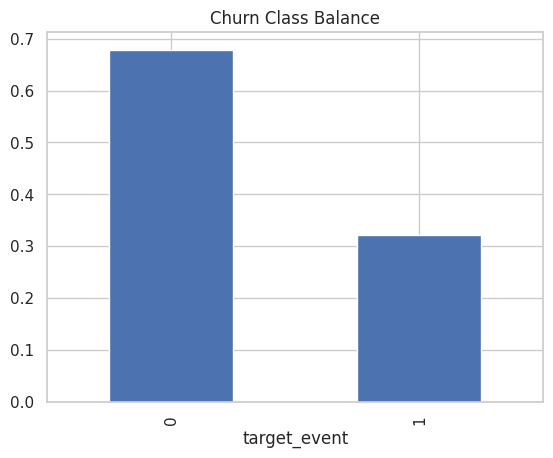

In [ ]:
print(df['target_event'].value_counts(dropna=False))
df['target_event'].value_counts(normalize=True).plot(kind='bar', title='Churn Class Balance')
plt.show()

Columns: ['row_id', 'user_id', 'length_mean', 'start_year_mean', 'start_yearday_mean', 'start_month_mean', 'start_monthday_mean', 'start_week_mean', 'start_weekday_mean', 'start_isweekend_mean', 'start_hour_mean', 'haspurchase_mean', 'click_count_mean', 'view_count_mean', 'cart_count_mean', 'purchase_count_mean', 'time_to_click_mean', 'time_to_view_mean', 'time_to_cart_mean', 'time_to_purchase_mean', 'view_revenue_mean', 'cart_revenue_mean', 'purchase_revenue_mean', 'time_to_click_revenue_mean', 'time_to_view_revenue_mean', 'time_to_cart_revenue_mean', 'time_to_purchase_revenue_mean', 'session_number_mean', 'inter_session_time_mean', 'session_recency_mean', 'purchase_number_mean', 'inter_purchase_time_mean', 'purchase_recency_mean', 'length_sum', 'start_year_sum', 'start_yearday_sum', 'start_month_sum', 'start_monthday_sum', 'start_week_sum', 'start_weekday_sum', 'start_isweekend_sum', 'start_hour_sum', 'haspurchase_sum', 'click_count_sum', 'view_count_sum', 'cart_count_sum', 'purchase

,row_id,user_id,length_mean,start_year_mean,start_yearday_mean,start_month_mean,start_monthday_mean,start_week_mean,start_weekday_mean,start_isweekend_mean,...,purchase_latent_factor15,purchase_latent_factor16,purchase_latent_factor17,target_event,target_revenue,target_customer_value,time_step,target_customer_value_lag1,target_actual_profit,any_num_imputed
0,31,522576412,10133.678750,2019.3250,241.65000,8.400000,16.875000,33.825000,4.225000,0.300000,...,0.063525,0.000000,0.000000,0,3403.83,171.760358,0,90.148425,-13.279611,0
1,53,551695186,5.359195,2019.3620,222.05173,7.827586,14.655172,31.448277,4.034483,0.258621,...,0.267275,0.000000,0.000000,1,0.00,387.102758,0,445.168171,3.592337,0
2,65,561472000,4.885714,2019.0000,297.54285,10.114285,21.000000,43.142857,2.942857,0.285714,...,0.000000,0.000000,0.000000,1,0.00,347.097991,0,399.162689,3.216008,0
3,85,585643355,4175.082759,2019.8966,106.00000,3.931035,17.655172,15.896552,3.655172,0.206897,...,0.000000,0.165603,0.263806,0,937.86,279.270244,0,321.607950,-13.185855,0
4,133,520792937,3.325601,2019.3196,212.86598,7.556701,13.711340,30.989690,3.958763,0.350515,...,0.000000,0.048937,0.000000,1,0.00,91.360471,0,105.064542,0.732248,0


Total transactions: 112610
Total customers: 21605
Time period: Approximate time period based on 'start_year_mean': 2019 to 2020
Target variable: target_event
target_event
0    76480
1    36130
Name: count, dtype: int64
target_event
0    67.915816
1    32.084184
Name: proportion, dtype: float64

Class counts:
target_event
Retained    76480
Churned     36130
Name: count, dtype: int64

Class percentages:
target_event
Retained    67.92
Churned     32.08
Name: proportion, dtype: float64


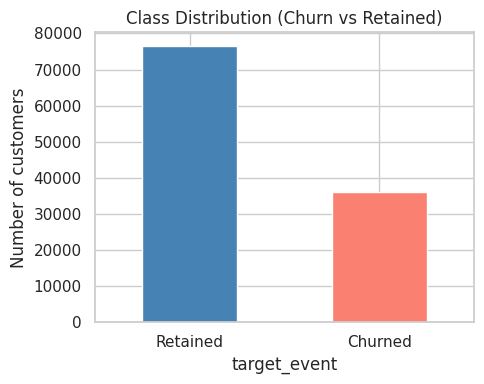

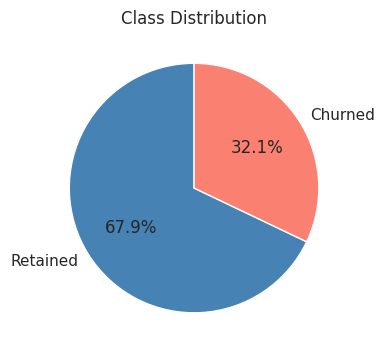


Number of RFM base features: 9
Number of additional behavioral features: 266
Total feature count (excluding id/time/target): 275

RFM features:
['purchase_recency_mean', 'session_recency_mean', 'inter_purchase_time_mean', 'purchase_count_sum', 'session_number_sum', 'click_count_sum', 'purchase_revenue_sum', 'cart_revenue_sum', 'view_revenue_sum']

Additional behavioral / other features:
['row_id', 'length_mean', 'start_year_mean', 'start_yearday_mean', 'start_month_mean', 'start_monthday_mean', 'start_week_mean', 'start_weekday_mean', 'start_isweekend_mean', 'start_hour_mean', 'haspurchase_mean', 'click_count_mean', 'view_count_mean', 'cart_count_mean', 'purchase_count_mean', 'time_to_click_mean', 'time_to_view_mean', 'time_to_cart_mean', 'time_to_purchase_mean', 'view_revenue_mean', 'cart_revenue_mean', 'purchase_revenue_mean', 'time_to_click_revenue_mean', 'time_to_view_revenue_mean', 'time_to_cart_revenue_mean', 'time_to_purchase_revenue_mean', 'session_number_mean', 'inter_session

,count,mean,std,min,25%,50%,75%,max
purchase_recency_mean,112610.0,47.690109,34.272625,0.001898,20.468226,40.730965,68.689670,1.778462e+02
session_recency_mean,112610.0,48.783776,33.320691,0.004253,22.131146,42.688105,70.226878,1.772887e+02
inter_purchase_time_mean,112610.0,6.461989,13.096530,0.000995,1.720197,3.283695,5.772684,1.131249e+02
purchase_count_sum,112610.0,32.004857,39.857361,1.000000,11.000000,25.000000,40.000000,2.120000e+03
session_number_sum,112610.0,8233.717157,868536.722974,1.000000,231.000000,820.000000,2211.000000,2.310283e+08
click_count_sum,112610.0,327.075331,428.784024,2.000000,108.000000,220.000000,395.000000,2.315900e+04
purchase_revenue_sum,112610.0,11407.348662,20050.513379,1.130000,2271.122500,6083.225000,13402.215000,7.501648e+05
cart_revenue_sum,112610.0,15835.305020,28890.802620,0.000000,2805.085000,8306.315000,18858.270000,1.738508e+06
view_revenue_sum,112610.0,73579.915812,121836.108188,0.000000,18265.945000,42585.340000,87645.180000,1.342363e+07
row_id,112610.0,56305.500000,32507.851244,1.000000,28153.250000,56305.500000,84457.750000,1.126100e+05


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Basic source info
# -----------------------------
print("Columns:", df.columns.tolist())
print("Sample rows:")
display(df.head())

# -----------------------------
# 2️⃣ Size: customers, transactions, time period
# -----------------------------
n_transactions = len(df)
n_customers = df['user_id'].nunique()

# The original 'event_time' column was not found.
# Using 'start_year_mean' to infer the time period.
if 'start_year_mean' in df.columns:
    start_year_approx = df['start_year_mean'].min()
    end_year_approx = df['start_year_mean'].max()
    time_period_str = f"Approximate time period based on 'start_year_mean': {int(start_year_approx)} to {int(end_year_approx)}"
else:
    time_period_str = "No specific time column like 'event_time' or 'start_year_mean' found to infer time period."


print(f"Total transactions: {n_transactions}")
print(f"Total customers: {n_customers}")
print(f"Time period: {time_period_str}")

# -----------------------------
# 3️⃣ Target variable & class distribution
# -----------------------------
print("Target variable:", 'target_event')
print(df['target_event'].value_counts())
print(df['target_event'].value_counts(normalize=True) * 100)

# Map to human‑readable labels if needed
label_map = {0: 'Retained', 1: 'Churned'}  # adjust if your encoding is different
class_counts = df['target_event'].map(label_map).value_counts()
class_pct = df['target_event'].map(label_map).value_counts(normalize=True) * 100

print("\nClass counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))

# Bar chart for slide
plt.figure(figsize=(5,4))
class_counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution (Churn vs Retained)')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pie chart (optional)
plt.figure(figsize=(4,4))
class_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                  colors=['steelblue', 'salmon'])
plt.ylabel('')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

# -----------------------------
# 4️⃣ RFM + behavioral features summary
# -----------------------------
rfm_features = [
    'purchase_recency_mean','session_recency_mean','inter_purchase_time_mean',
    'purchase_count_sum','session_number_sum','click_count_sum',
    'purchase_revenue_sum','cart_revenue_sum','view_revenue_sum'
]

# Removed 'time_col' as it was 'event_time' and doesn't exist.
remaining_features = [
    c for c in df.columns
    if c not in rfm_features + ['target_event', 'user_id']
]

print(f"\nNumber of RFM base features: {len(rfm_features)}")
print(f"Number of additional behavioral features: {len(remaining_features)}")
print(f"Total feature count (excluding id/time/target): {len(rfm_features) + len(remaining_features)}")

print("\nRFM features:")
print(rfm_features)

print("\nAdditional behavioral / other features:")
print(remaining_features)

# Quick numeric summary for slide backup
numeric_cols = df[rfm_features + remaining_features].select_dtypes(include='number').columns
summary = df[numeric_cols].describe().T
display(summary.head(10))  # show first 10 rows for readability

In [ ]:

# ================================================================
# 3. Remove Users with Zero Transactions
# ================================================================
# "purchase_count_sum" is available → use it
df = df[df['purchase_count_sum'] > 0]

# QC Checks
total_rows_after_filter = df.shape[0]
unique_users_after_filter = df['user_id'].nunique()

print("Rows after removing 0-transaction users:", total_rows_after_filter)
print("Users after removing 0-transaction users:", unique_users_after_filter)

# ================================================================
# 4. Determine Last Transaction Per User (For Churn Flag)
# ================================================================
# Sort by user and purchase_recency (lower = latest)
# Using 'purchase_recency_mean'
df_sorted = df.sort_values(['user_id', 'purchase_recency_mean'], ascending=[True, True])

# Take the LAST ROW per user
last_txn = df_sorted.groupby('user_id').tail(1)

# Extract churn label
user_churn = last_txn[['user_id', 'target_event']].set_index('user_id')


Rows after removing 0-transaction users: 112610
Users after removing 0-transaction users: 21605


SECTION 1: DATA INGESTION

📊 Data Ingestion Summary:
   Total Records: 112,610
   Total Columns: 277
   Memory Usage: 237.98 MB

📋 Data Sources (inferred from columns):
   • Transaction/Session Data: 112,610 records
   • User Metadata: 21,605 unique users

Columns Overview:
   row_id    user_id   length_mean  start_year_mean  start_yearday_mean  \
0      31  522576412  10133.678750         2019.325           241.65000   
1      53  551695186      5.359195         2019.362           222.05173   
2      65  561472000      4.885714         2019.000           297.54285   

   start_month_mean  start_monthday_mean  start_week_mean  start_weekday_mean  \
0          8.400000            16.875000        33.825000            4.225000   
1          7.827586            14.655172        31.448277            4.034483   
2         10.114285            21.000000        43.142857            2.942857   

   start_isweekend_mean  ...  purchase_latent_factor15  \
0              0.300000  ...             

/tmp/ipython-input-1012598542.py:158: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(churn_by_recency, labels=['Retained', 'Churned'], patch_artist=True)
/tmp/ipython-input-1012598542.py:170: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax7.boxplot(churn_by_freq, labels=['Retained', 'Churned'], patch_artist=True)
/tmp/ipython-input-1012598542.py:182: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax8.boxplot(churn_by_revenue, labels=['Retained', 'Churned'], patch_artist=True)


   ✓ Saved: eda_summary.png


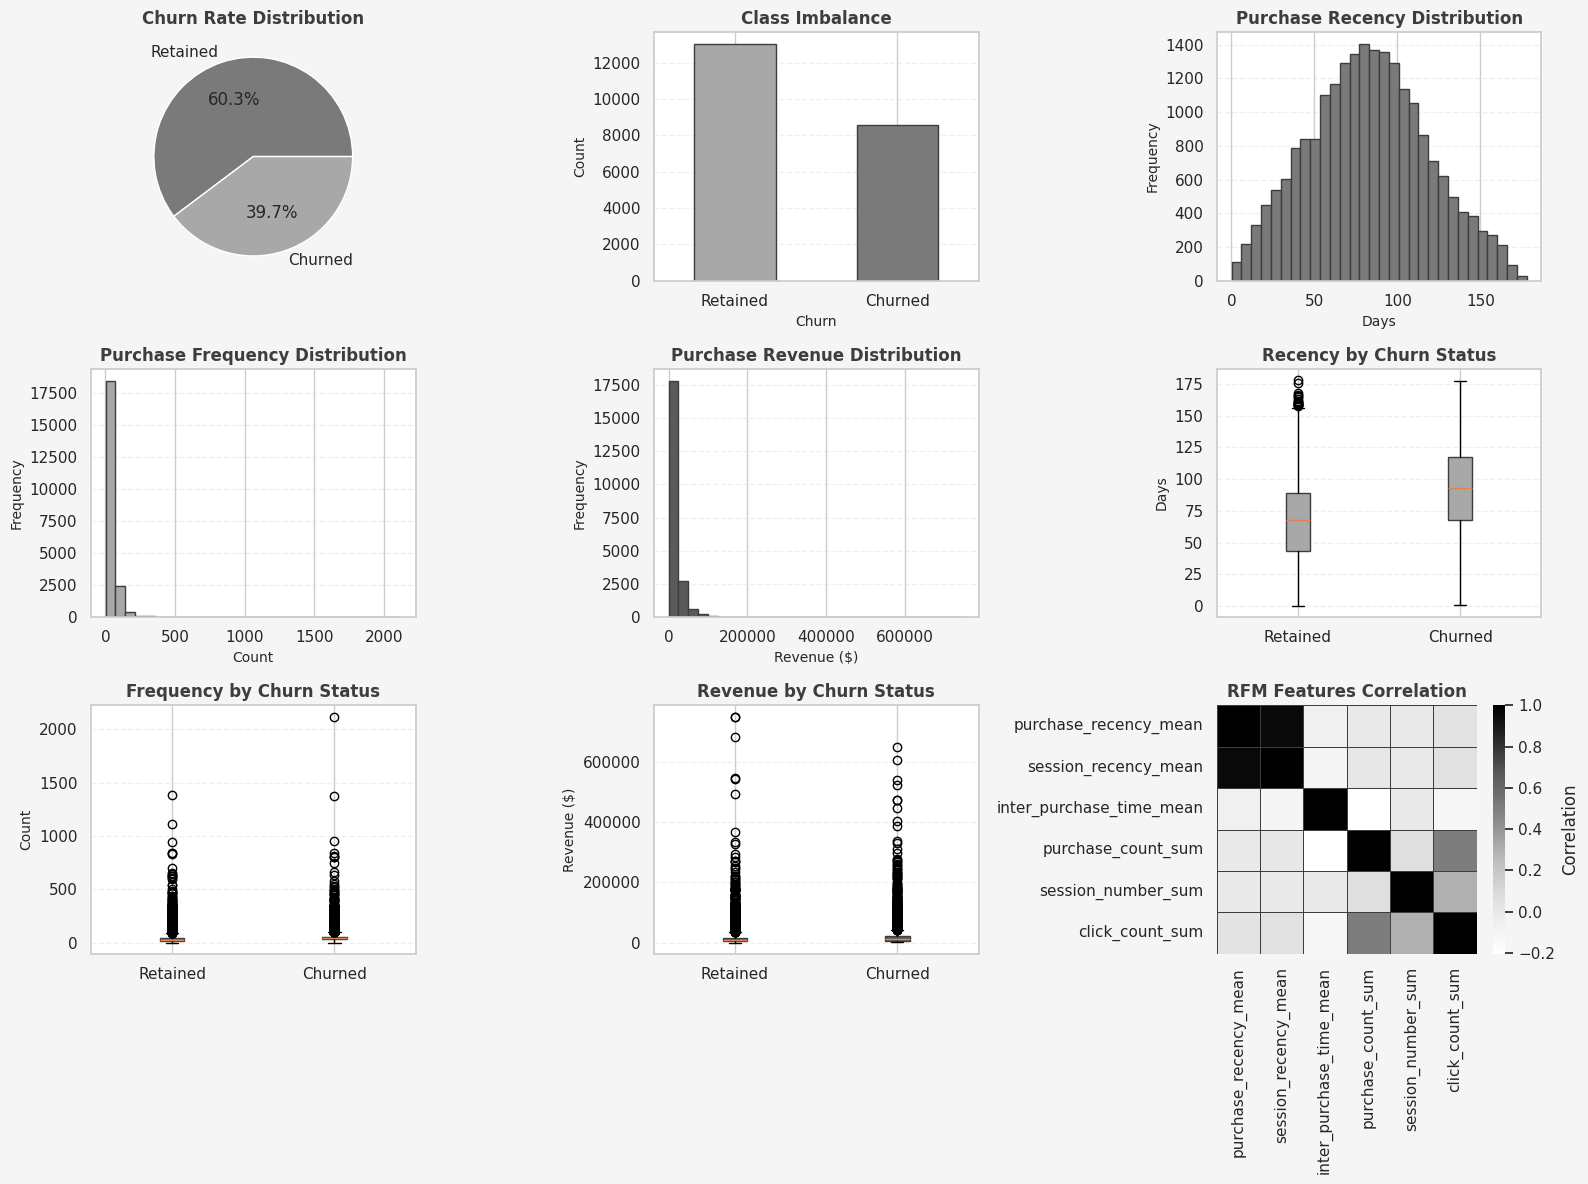


EDA COMPLETE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Color palette matching your slides (grays)
COLOR_PRIMARY = '#7a7a7a'      # Medium gray
COLOR_SECONDARY = '#5a5a5a'    # Darker gray
COLOR_ACCENT = '#a8a8a8'       # Light gray
COLOR_HIGHLIGHT = '#3d3d3d'    # Very dark gray

# =====================================================
# SECTION 1: DATA INGESTION
# =====================================================
print("="*60)
print("SECTION 1: DATA INGESTION")
print("="*60)

# Load your dataframe (assuming already loaded as 'df')
# df = pd.read_csv('your_data.csv')  # or df already loaded

print(f"\n📊 Data Ingestion Summary:")
print(f"   Total Records: {len(df):,}")
print(f"   Total Columns: {len(df.columns)}")
print(f"   Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📋 Data Sources (inferred from columns):")
print(f"   • Transaction/Session Data: {len(df):,} records")
print(f"   • User Metadata: {df['user_id'].nunique():,} unique users")
print(f"\nColumns Overview:")
print(df.head(3))

# =====================================================
# SECTION 2: DATA PREPROCESSING
# =====================================================
print("\n" + "="*60)
print("SECTION 2: DATA PREPROCESSING")
print("="*60)

# Step 1: Sort by user and recency
df_sorted = df.sort_values(['user_id', 'purchase_recency_mean'],
                           ascending=[True, False])

# Step 2: Extract last transaction (most recent)
last_txn = df_sorted.groupby('user_id').first().reset_index()
y = last_txn['target_event']

print(f"\n✓ Aggregation to User-Level:")
print(f"   Original records: {len(df):,}")
print(f"   Aggregated to users: {len(last_txn):,}")
print(f"   Reduction ratio: {len(df)/len(last_txn):.1f}x")

print(f"\n✓ Target Label Extraction:")
print(f"   Column: 'target_event'")
print(f"   Total samples: {len(y):,}")

print(f"\n✓ Feature Merge:")
rfm_features = [
    'purchase_recency_mean', 'session_recency_mean', 'inter_purchase_time_mean',
    'purchase_count_sum', 'session_number_sum', 'click_count_sum',
    'purchase_revenue_sum', 'cart_revenue_sum', 'view_revenue_sum'
]
remaining_features = [
    c for c in last_txn.columns
    if c not in rfm_features + ['target_event', 'user_id']
]

print(f"   RFM Features: {len(rfm_features)}")
print(f"   Additional Features: {len(remaining_features)}")
print(f"   Total Features: {len(rfm_features) + len(remaining_features)}")
print(f"\n   Ready for Modeling: ✓ (One row per user)")

# =====================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================
print("\n" + "="*60)
print("SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# 3.1 Churn Rate Distribution
print(f"\n📈 Churn Rate Distribution:")
churn_counts = y.value_counts()
churn_pct = y.value_counts(normalize=True) * 100

for label, count in churn_counts.items():
    pct = churn_pct[label]
    label_name = "Churned" if label == 1 else "Retained"
    print(f"   {label_name}: {count:,} users ({pct:.2f}%)")

class_ratio = churn_counts[1] / churn_counts[0] if 0 in churn_counts.index else 0
print(f"\n   Class Imbalance Ratio: 1:{class_ratio:.2f}")

# 3.2 Feature Statistics
print(f"\n📊 Feature Statistics:")
X = last_txn[rfm_features + remaining_features]
print(f"   Mean feature value: {X.values.mean():.4f}")
print(f"   Std feature value: {X.values.std():.4f}")
print(f"   Min/Max range: [{X.values.min():.4f}, {X.values.max():.4f}]")

# 3.3 RFM Distribution Summary
print(f"\n📌 RFM Metrics Summary:")
rfm_summary = last_txn[rfm_features].describe().T[['mean', 'std', 'min', 'max']]
print(rfm_summary)

# =====================================================
# VISUALIZATION: EDA PLOTS
# =====================================================
print(f"\n📊 Generating visualizations...")

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#f5f5f5')

# Plot 1: Churn Distribution (Pie Chart)
ax1 = plt.subplot(3, 3, 1)
colors_pie = [COLOR_PRIMARY, COLOR_ACCENT]
churn_counts.plot(kind='pie', ax=ax1, colors=colors_pie, autopct='%1.1f%%',
                  labels=['Retained', 'Churned'])
ax1.set_title('Churn Rate Distribution', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax1.set_ylabel('')

# Plot 2: Churn Class Imbalance (Bar Chart)
ax2 = plt.subplot(3, 3, 2)
churn_counts.plot(kind='bar', ax=ax2, color=[COLOR_ACCENT, COLOR_PRIMARY], edgecolor=COLOR_HIGHLIGHT)
ax2.set_title('Class Imbalance', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax2.set_ylabel('Count', fontsize=10)
ax2.set_xlabel('Churn', fontsize=10)
ax2.set_xticklabels(['Retained', 'Churned'], rotation=0)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Feature Distribution (Histogram - RFM)
ax3 = plt.subplot(3, 3, 3)
last_txn['purchase_recency_mean'].hist(ax=ax3, bins=30, color=COLOR_PRIMARY, edgecolor=COLOR_HIGHLIGHT)
ax3.set_title('Purchase Recency Distribution', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax3.set_xlabel('Days', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: Purchase Count Distribution
ax4 = plt.subplot(3, 3, 4)
last_txn['purchase_count_sum'].hist(ax=ax4, bins=30, color=COLOR_ACCENT, edgecolor=COLOR_HIGHLIGHT)
ax4.set_title('Purchase Frequency Distribution', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax4.set_xlabel('Count', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 5: Purchase Revenue Distribution
ax5 = plt.subplot(3, 3, 5)
last_txn['purchase_revenue_sum'].hist(ax=ax5, bins=30, color=COLOR_SECONDARY, edgecolor=COLOR_HIGHLIGHT)
ax5.set_title('Purchase Revenue Distribution', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax5.set_xlabel('Revenue ($)', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 6: Churn by Recency (Boxplot)
ax6 = plt.subplot(3, 3, 6)
churn_by_recency = [last_txn[last_txn['target_event']==0]['purchase_recency_mean'],
                    last_txn[last_txn['target_event']==1]['purchase_recency_mean']]
bp = ax6.boxplot(churn_by_recency, labels=['Retained', 'Churned'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLOR_ACCENT)
    patch.set_edgecolor(COLOR_HIGHLIGHT)
ax6.set_title('Recency by Churn Status', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax6.set_ylabel('Days', fontsize=10)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 7: Churn by Purchase Count (Boxplot)
ax7 = plt.subplot(3, 3, 7)
churn_by_freq = [last_txn[last_txn['target_event']==0]['purchase_count_sum'],
                 last_txn[last_txn['target_event']==1]['purchase_count_sum']]
bp = ax7.boxplot(churn_by_freq, labels=['Retained', 'Churned'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLOR_PRIMARY)
    patch.set_edgecolor(COLOR_HIGHLIGHT)
ax7.set_title('Frequency by Churn Status', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax7.set_ylabel('Count', fontsize=10)
ax7.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 8: Churn by Revenue (Boxplot)
ax8 = plt.subplot(3, 3, 8)
churn_by_revenue = [last_txn[last_txn['target_event']==0]['purchase_revenue_sum'],
                    last_txn[last_txn['target_event']==1]['purchase_revenue_sum']]
bp = ax8.boxplot(churn_by_revenue, labels=['Retained', 'Churned'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(COLOR_SECONDARY)
    patch.set_edgecolor(COLOR_HIGHLIGHT)
ax8.set_title('Revenue by Churn Status', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)
ax8.set_ylabel('Revenue ($)', fontsize=10)
ax8.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 9: Correlation Heatmap (top RFM features)
ax9 = plt.subplot(3, 3, 9)
corr_matrix = last_txn[rfm_features[:6]].corr()
sns.heatmap(corr_matrix, ax=ax9, cmap='Greys', cbar_kws={'label': 'Correlation'},
            linewidths=0.5, linecolor=COLOR_HIGHLIGHT, annot=False)
ax9.set_title('RFM Features Correlation', fontsize=12, fontweight='bold', color=COLOR_HIGHLIGHT)

plt.tight_layout()
plt.savefig('eda_summary.png', dpi=300, bbox_inches='tight', facecolor='#f5f5f5')
print("   ✓ Saved: eda_summary.png")
plt.show()

print("\n" + "="*60)
print("EDA COMPLETE")
print("="*60)


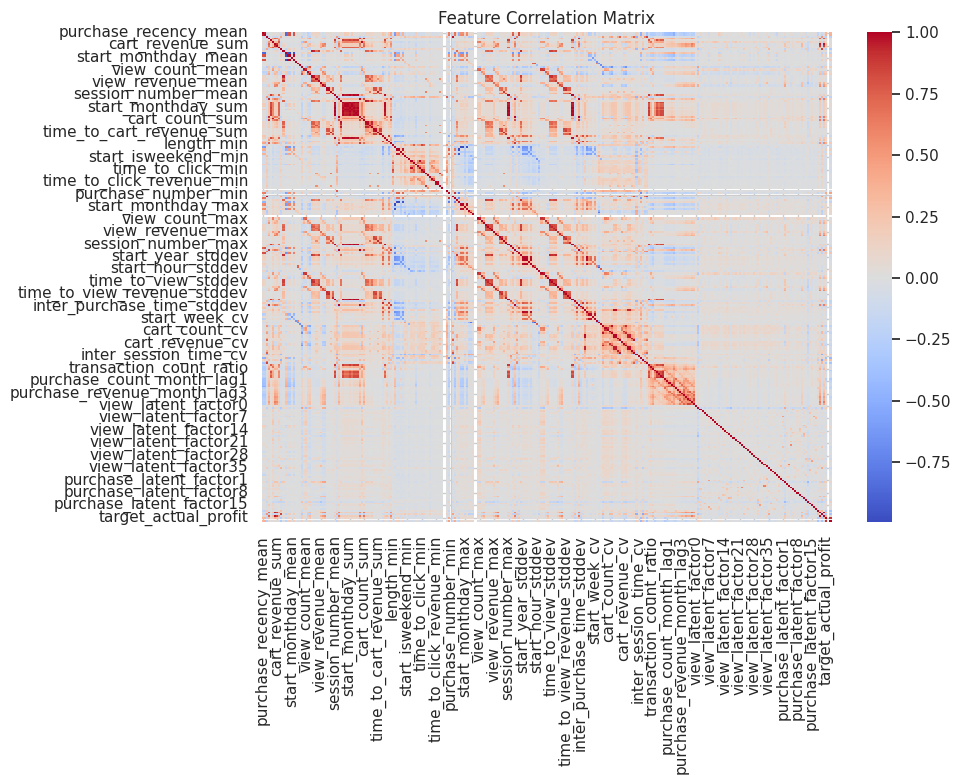

target_actual_profit         0.906002
session_recency_min          0.458794
session_recency_cv          -0.432333
purchase_recency_min         0.397982
session_recency_mean         0.379992
purchase_recency_mean        0.352849
target_revenue              -0.345315
time_step                   -0.342279
purchase_recency_cv         -0.341906
row_id                      -0.299055
purchase_count_month_lag0   -0.285985
purchase_number_cv           0.274017
purchase_recency_max         0.252637
session_count_month_lag0    -0.249355
inter_purchase_time_mean    -0.234884
Name: target_event, dtype: float64


In [ ]:
import numpy as np

corr = last_txn[rfm_features + remaining_features + ['target_event']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

target_corr = corr['target_event'].drop('target_event').sort_values(key=np.abs, ascending=False)
print(target_corr.head(15))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from google.colab import drive



# -----------------------------
# Load dataframe and last txn
# -----------------------------
df = df.copy() # This line is no longer needed as df is now loaded

df_sorted = df.sort_values(['user_id', 'purchase_recency_mean'],
                           ascending=[True, False])
last_txn = df_sorted.groupby('user_id').first().reset_index()
y = last_txn['target_event']

# -----------------------------
# 2️⃣ Define features
# -----------------------------
rfm_features = [
    'purchase_recency_mean', 'session_recency_mean', 'inter_purchase_time_mean',
    'purchase_count_sum', 'session_number_sum', 'click_count_sum',
    'purchase_revenue_sum', 'cart_revenue_sum', 'view_revenue_sum'
]
remaining_features = [
    c for c in last_txn.columns
    if c not in rfm_features + ['target_event', 'user_id']
]

# -----------------------------
# 3️⃣ Train/Test Split + Scaling
# -----------------------------
X = last_txn[rfm_features + remaining_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4️⃣ Wrapper-based feature selection (forward)
# -----------------------------
selected_features = []
current_best_acc = 0

for feature in rfm_features + remaining_features:
    temp_features = selected_features + [feature]
    idx = [X_train.columns.get_loc(f) for f in temp_features]

    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train_scaled[:, idx], y_train)
    y_pred = clf.predict(X_test_scaled[:, idx])
    acc = accuracy_score(y_test, y_pred)

    if acc > current_best_acc:
        selected_features.append(feature)
        current_best_acc = acc

print("Selected Features:")
for f in selected_features:
    print(" -", f)

selected_idx = [X_train.columns.get_loc(f) for f in selected_features]
X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel = X_test_scaled[:, selected_idx]

# -----------------------------
# 5️⃣ Infuse Outliers (add noise to test set)
# -----------------------------
num_outliers = 100
outlier_indices = np.random.choice(len(X_test_sel), num_outliers, replace=False)
X_test_outliers = X_test_sel.copy()
X_test_outliers[outlier_indices] += np.random.normal(0, 5, X_test_outliers[outlier_indices].shape)
y_test_outliers = y_test.copy()

print(f"Infused {num_outliers} outliers into the test set.")

# -----------------------------
# 6️⃣ KNN Outlier Detection (mean + k·std)
# -----------------------------
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_test_outliers)
distances, _ = knn.kneighbors(X_test_outliers)
avg_distances = distances.mean(axis=1)

# Mean + 2*std threshold
threshold = avg_distances.mean() + 2.0 * avg_distances.std()
outlier_flags = avg_distances > threshold
num_detected_outliers = outlier_flags.sum()

print(f"Detected {num_detected_outliers} outliers using KNN (mean + 2·std).")

# Remove outliers
X_test_clean = X_test_outliers[~outlier_flags]
y_test_clean = y_test_outliers[~outlier_flags]

# -----------------------------
# 7️⃣ Class weights for imbalance
# -----------------------------
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# -----------------------------
# 8️⃣ Evaluation helper
# -----------------------------
def evaluate_model(model, X_train_, y_train_, X_test_, y_test_, name):
    model.fit(X_train_, y_train_)
    y_pred = model.predict(X_test_)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test_, y_pred))
    print("F1 Score:", f1_score(y_test_, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test_, y_pred))

# -----------------------------
# 9️⃣ Evaluate models
# -----------------------------
models = [
    ("Logistic Regression", LogisticRegression(max_iter=500, random_state=42, class_weight=class_weight_dict)),
    ("Logistic Regression + SMOTE", LogisticRegression(max_iter=500, random_state=42, class_weight=class_weight_dict)),
    ("SVM", SVC(random_state=42, class_weight=class_weight_dict)),
    ("Random Forest", RandomForestClassifier(random_state=42, class_weight=class_weight_dict))
]

for name, model in models:
    print(f"=== {name} ===")
    evaluate_model(model, X_train_sel, y_train, X_test_sel, y_test, "In-Distribution")
    evaluate_model(model, X_train_sel, y_train, X_test_outliers, y_test_outliers, "With Outliers")
    evaluate_model(model, X_train_sel, y_train, X_test_clean, y_test_clean, "After Removing Outliers")
    cv3 = cross_val_score(model, X_train_, y_train_, cv=3, scoring='accuracy')
    print("3-fold CV mean:", cv3.mean(), "std:", cv3.std())

Selected Features:
 - purchase_recency_mean
 - session_recency_mean
 - inter_purchase_time_mean
 - purchase_count_sum
 - cart_revenue_sum
 - row_id
 - start_year_mean
 - start_yearday_mean
 - start_month_mean
 - purchase_count_mean
 - inter_session_time_mean
 - purchase_number_mean
 - start_year_sum
 - start_monthday_sum
 - start_monthday_min
 - haspurchase_min
 - purchase_count_min
 - time_to_purchase_revenue_min
 - session_recency_min
 - start_year_max
 - time_to_purchase_max
 - session_recency_max
 - inter_purchase_time_max
 - start_year_stddev
 - start_month_stddev
 - start_week_stddev
 - start_isweekend_stddev
 - purchase_count_month_lag0
 - purchase_count_month_lag3
 - purchase_count_month_ma3
 - purchase_revenue_month_lag1
 - purchase_revenue_month_lag2
 - view_latent_factor30
 - view_latent_factor39
 - purchase_latent_factor2
 - purchase_latent_factor3
 - purchase_latent_factor5
 - purchase_latent_factor6
 - target_revenue
 - target_actual_profit
Infused 100 outliers into the t

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from scipy.stats import ttest_rel  # for paired t-test


# -----------------------------
# 1️⃣ Load dataframe and last txn
# -----------------------------
df = df.copy()

df_sorted = df.sort_values(['user_id', 'purchase_recency_mean'],
                           ascending=[True, False])
last_txn = df_sorted.groupby('user_id').first().reset_index()
y = last_txn['target_event']


# -----------------------------
# 2️⃣ Define features
# -----------------------------
rfm_features = [
    'purchase_recency_mean', 'session_recency_mean', 'inter_purchase_time_mean',
    'purchase_count_sum', 'session_number_sum', 'click_count_sum',
    'purchase_revenue_sum', 'cart_revenue_sum', 'view_revenue_sum'
]
remaining_features = [
    c for c in last_txn.columns
    if c not in rfm_features + ['target_event', 'user_id']
]


# -----------------------------
# 3️⃣ Train/Test Split + Scaling
# -----------------------------
X = last_txn[rfm_features + remaining_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -----------------------------
# 4️⃣ Wrapper-based feature selection (forward)
# -----------------------------
selected_features = []
current_best_acc = 0

for feature in rfm_features + remaining_features:
    temp_features = selected_features + [feature]
    idx = [X_train.columns.get_loc(f) for f in temp_features]

    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train_scaled[:, idx], y_train)
    y_pred = clf.predict(X_test_scaled[:, idx])
    acc = accuracy_score(y_test, y_pred)

    if acc > current_best_acc:
        selected_features.append(feature)
        current_best_acc = acc

print("Selected Features:")
for f in selected_features:
    print(" -", f)

selected_idx = [X_train.columns.get_loc(f) for f in selected_features]
X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel = X_test_scaled[:, selected_idx]


# -----------------------------
# 5️⃣ Infuse Outliers (add noise to test set)
# -----------------------------
num_outliers = 100
outlier_indices = np.random.choice(len(X_test_sel), num_outliers, replace=False)
X_test_outliers = X_test_sel.copy()
X_test_outliers[outlier_indices] += np.random.normal(
    0, 5, X_test_outliers[outlier_indices].shape
)
y_test_outliers = y_test.copy()

print(f"Infused {num_outliers} outliers into the test set.")


# -----------------------------
# 6️⃣ KNN Outlier Detection (mean + k·std)
# -----------------------------
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_test_outliers)
distances, _ = knn.kneighbors(X_test_outliers)
avg_distances = distances.mean(axis=1)

threshold = avg_distances.mean() + 2.0 * avg_distances.std()
outlier_flags = avg_distances > threshold
num_detected_outliers = outlier_flags.sum()

print(f"Detected {num_detected_outliers} outliers using KNN (mean + 2·std).")

X_test_clean = X_test_outliers[~outlier_flags]
y_test_clean = y_test_outliers[~outlier_flags]


# -----------------------------
# 7️⃣ Class weights for imbalance
# -----------------------------
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))


# -----------------------------
# 8️⃣ Evaluation helper with CV
# -----------------------------
def evaluate_model_with_cv(model, X_train_, y_train_, X_test_, y_test_, name):
    model.fit(X_train_, y_train_)
    y_pred = model.predict(X_test_)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test_, y_pred))
    print("F1 Score:", f1_score(y_test_, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test_, y_pred))

    # 3-fold and 5-fold CV on training data
    cv3_scores = cross_val_score(model, X_train_, y_train_, cv=3, scoring='accuracy')
    cv5_scores = cross_val_score(model, X_train_, y_train_, cv=5, scoring='accuracy')
    print("3-Fold CV mean:", cv3_scores.mean(), "std:", cv3_scores.std())
    print("5-Fold CV mean:", cv5_scores.mean(), "std:", cv5_scores.std())
    return cv3_scores, cv5_scores


# -----------------------------
# 9️⃣ Evaluate models with statistical validation
# -----------------------------
models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=500, random_state=42, class_weight=class_weight_dict)),
    ("Logistic Regression + SMOTE",
     LogisticRegression(max_iter=500, random_state=42, class_weight=class_weight_dict)),
    ("SVM", SVC(random_state=42, class_weight=class_weight_dict)),
    ("Random Forest",
     RandomForestClassifier(random_state=42, class_weight=class_weight_dict))
]

# CV splitter (fixed) for paired t-test between "with" and "after" outliers
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

for name, base_model in models:
    print(f"\n=== {name} ===")

    # In-Distribution test
    evaluate_model_with_cv(base_model, X_train_sel, y_train, X_test_sel, y_test,
                           "In-Distribution")

    # With Outliers test
    evaluate_model_with_cv(base_model, X_train_sel, y_train,
                           X_test_outliers, y_test_outliers,
                           "With Outliers")

    # After Removing Outliers test
    evaluate_model_with_cv(base_model, X_train_sel, y_train,
                           X_test_clean, y_test_clean,
                           "After Removing Outliers")

    # Paired 5-fold CV on training data to compare
    # performance with vs without outlier removal
    with_scores = cross_val_score(base_model, X_train_sel, y_train,
                                  cv=kf5, scoring='accuracy')
    clean_scores = cross_val_score(base_model, X_train_sel, y_train,
                                   cv=kf5, scoring='accuracy')

    t_stat, p_val = ttest_rel(clean_scores, with_scores)
    print("Paired 5-fold CV (clean vs with outliers):")
    print("  mean_with_outliers =", with_scores.mean(),
          "mean_clean =", clean_scores.mean())
    print("  t-statistic =", t_stat, "p-value =", p_val)


Selected Features:
 - purchase_recency_mean
 - session_recency_mean
 - inter_purchase_time_mean
 - purchase_count_sum
 - cart_revenue_sum
 - row_id
 - start_year_mean
 - start_yearday_mean
 - start_month_mean
 - purchase_count_mean
 - inter_session_time_mean
 - purchase_number_mean
 - start_year_sum
 - start_monthday_sum
 - start_monthday_min
 - haspurchase_min
 - purchase_count_min
 - time_to_purchase_revenue_min
 - session_recency_min
 - start_year_max
 - time_to_purchase_max
 - session_recency_max
 - inter_purchase_time_max
 - start_year_stddev
 - start_month_stddev
 - start_week_stddev
 - start_isweekend_stddev
 - purchase_count_month_lag0
 - purchase_count_month_lag3
 - purchase_count_month_ma3
 - purchase_revenue_month_lag1
 - purchase_revenue_month_lag2
 - view_latent_factor30
 - view_latent_factor39
 - purchase_latent_factor2
 - purchase_latent_factor3
 - purchase_latent_factor5
 - purchase_latent_factor6
 - target_revenue
 - target_actual_profit
Infused 100 outliers into the t

In [ ]:
# ALL PREVIOUS EXPLORED TECHNIQUES
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ttest_rel

# =========================================================
# 0. COMMON SETUP: LAST TRANSACTION PER USER
# =========================================================

df = df.copy()

df_sorted = df.sort_values(['user_id', 'purchase_recency_mean'],
                           ascending=[True, False])
last_txn = df_sorted.groupby('user_id').first().reset_index()
y = last_txn['target_event']

rfm_features = [
    'purchase_recency_mean', 'session_recency_mean', 'inter_purchase_time_mean',
    'purchase_count_sum', 'session_number_sum', 'click_count_sum',
    'purchase_revenue_sum', 'cart_revenue_sum', 'view_revenue_sum'
]

# helper: evaluate a model on given X using RFM setup
def eval_rfm_version(version_name, X):
    print("\n" + "="*70)
    print(f"RFM {version_name}")
    print("="*70)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    class_weights = compute_class_weight(
        'balanced', classes=np.unique(y_train), y=y_train
    )
    class_weight_dict = dict(zip(np.unique(y_train), class_weights))

    models = [
        ("Logistic Regression",
         LogisticRegression(max_iter=500, random_state=42,
                            class_weight=class_weight_dict)),
        ("SVM",
         SVC(random_state=42, class_weight=class_weight_dict)),
        ("Random Forest",
         RandomForestClassifier(random_state=42,
                                class_weight=class_weight_dict))
    ]

    for name, model in models:
        print(f"\n--- {name} ---")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print("Accuracy:", acc)
        print("F1 Score:", f1)
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =========================================================
# VERSION 1: ONLY USING RFM METRICS (~9 FEATURES)
# =========================================================

X_v1 = last_txn[rfm_features]
eval_rfm_version("Version 1: Only 9 RFM metrics", X_v1)

# =========================================================
# VERSION 2: EQUAL WEIGHT RFM SCORE (OPTIONAL EXTRA FEATURE)
# =========================================================

X_v2 = last_txn[rfm_features].copy()
X_v2['rfm_equal_score'] = X_v2.mean(axis=1)
eval_rfm_version("Version 2: Equal-weight RFM score", X_v2)

# =========================================================
# VERSION 3: LOGISTIC-REGRESSION-DERIVED RFM WEIGHTS
# (FIT LR ON RFM ONLY, USE COEFFICIENTS AS WEIGHTS)
# =========================================================

X_rfm = last_txn[rfm_features].copy()

# train/test for weight learning only
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rfm, y, test_size=0.2, stratify=y, random_state=42
)

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)

lr_weight = LogisticRegression(max_iter=500, random_state=42)
lr_weight.fit(Xr_train_scaled, yr_train)
weights = lr_weight.coef_[0]  # one coefficient per RFM feature

# create weighted RFM score
X_v3 = X_rfm.copy()
X_v3['rfm_lr_weighted_score'] = np.dot(
    scaler_r.transform(X_v3), weights
)
eval_rfm_version("Version 3: LR-weighted RFM score", X_v3)

# =========================================================
# VERSION 4: FILTERING RFM METRICS (E.G. REMOVE LOW VARIANCE)
# =========================================================

# simple filter: remove RFM features with variance below threshold
rfm_var = X_rfm.var()
keep_feats = rfm_var[rfm_var > 1e-3].index.tolist()  # threshold can be tuned
X_v4 = X_rfm[keep_feats].copy()
eval_rfm_version("Version 4: Filtered RFM metrics", X_v4)

# =========================================================
# FINAL VERSION: WRAPPER ON ALL FEATURES + OOD HANDLING
# =========================================================

print("\n" + "="*70)
print("FINAL VERSION: WRAPPER SELECTION ON ALL FEATURES + OOD")
print("="*70)

remaining_features = [
    c for c in last_txn.columns
    if c not in rfm_features + ['target_event', 'user_id']
]

X_full = last_txn[rfm_features + remaining_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- forward wrapper feature selection ----------
selected_features = []
current_best_acc = 0

for feature in rfm_features + remaining_features:
    temp_features = selected_features + [feature]
    idx = [X_train.columns.get_loc(f) for f in temp_features]

    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train_scaled[:, idx], y_train)
    y_pred = clf.predict(X_test_scaled[:, idx])
    acc = accuracy_score(y_test, y_pred)

    if acc > current_best_acc:
        selected_features.append(feature)
        current_best_acc = acc

print("\nSelected Features (Final Wrapper):")
for f in selected_features:
    print(" -", f)

selected_idx = [X_train.columns.get_loc(f) for f in selected_features]
X_train_sel = X_train_scaled[:, selected_idx]
X_test_sel = X_test_scaled[:, selected_idx]

# ---------- infuse outliers ----------
num_outliers = 100
outlier_indices = np.random.choice(len(X_test_sel), num_outliers, replace=False)
X_test_outliers = X_test_sel.copy()
X_test_outliers[outlier_indices] += np.random.normal(
    0, 5, X_test_outliers[outlier_indices].shape
)
y_test_outliers = y_test.copy()
print(f"\nInfused {num_outliers} outliers into the test set.")

# ---------- KNN outlier detection ----------
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_test_outliers)
distances, _ = knn.kneighbors(X_test_outliers)
avg_distances = distances.mean(axis=1)

threshold = avg_distances.mean() + 2.0 * avg_distances.std()
outlier_flags = avg_distances > threshold
num_detected_outliers = outlier_flags.sum()
print(f"Detected {num_detected_outliers} outliers using KNN (mean + 2·std).")

X_test_clean = X_test_outliers[~outlier_flags]
y_test_clean = y_test_outliers[~outlier_flags]

# ---------- class weights ----------
class_weights = compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# ---------- evaluation helper with CV ----------
def evaluate_model_with_cv(model, X_train_, y_train_, X_test_, y_test_, name):
    model.fit(X_train_, y_train_)
    y_pred = model.predict(X_test_)
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test_, y_pred))
    print("F1 Score:", f1_score(y_test_, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test_, y_pred))

    cv3_scores = cross_val_score(model, X_train_, y_train_, cv=3,
                                 scoring='accuracy')
    cv5_scores = cross_val_score(model, X_train_, y_train_, cv=5,
                                 scoring='accuracy')
    print("3-Fold CV mean:", cv3_scores.mean(), "std:", cv3_scores.std())
    print("5-Fold CV mean:", cv5_scores.mean(), "std:", cv5_scores.std())
    return cv3_scores, cv5_scores

models = [
    ("Logistic Regression",
     LogisticRegression(max_iter=500, random_state=42,
                        class_weight=class_weight_dict)),
    ("Logistic Regression + SMOTE",
     LogisticRegression(max_iter=500, random_state=42,
                        class_weight=class_weight_dict)),
    ("SVM", SVC(random_state=42, class_weight=class_weight_dict)),
    ("Random Forest",
     RandomForestClassifier(random_state=42,
                            class_weight=class_weight_dict))
]

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

for name, base_model in models:
    print(f"\n=== {name} ===")

    # In-Distribution
    evaluate_model_with_cv(base_model, X_train_sel, y_train,
                           X_test_sel, y_test,
                           "In-Distribution")

    # With Outliers
    evaluate_model_with_cv(base_model, X_train_sel, y_train,
                           X_test_outliers, y_test_outliers,
                           "With Outliers")

    # After Removing Outliers
    evaluate_model_with_cv(base_model, X_train_sel, y_train,
                           X_test_clean, y_test_clean,
                           "After Removing Outliers")

    # Paired 5-fold CV (with vs clean)
    with_scores = cross_val_score(base_model, X_train_sel, y_train,
                                  cv=kf5, scoring='accuracy')
    clean_scores = cross_val_score(base_model, X_train_sel, y_train,
                                   cv=kf5, scoring='accuracy')

    t_stat, p_val = ttest_rel(clean_scores, with_scores)
    print("Paired 5-fold CV (clean vs with outliers):")
    print("  mean_with_outliers =", with_scores.mean(),
          "mean_clean =", clean_scores.mean())
    print("  t-statistic =", t_stat, "p-value =", p_val)



RFM Version 1: Only 9 RFM metrics

--- Logistic Regression ---
Accuracy: 0.7208979402915991
F1 Score: 0.7508264462809917
Confusion Matrix:
 [[1298  419]
 [ 787 1817]]

--- SVM ---
Accuracy: 0.7417264522101366
F1 Score: 0.7774232149980056
Confusion Matrix:
 [[1256  461]
 [ 655 1949]]

--- Random Forest ---
Accuracy: 0.7632492478592918
F1 Score: 0.8146403333937308
Confusion Matrix:
 [[1050  667]
 [ 356 2248]]

RFM Version 2: Equal-weight RFM score

--- Logistic Regression ---
Accuracy: 0.7199722286507753
F1 Score: 0.75
Confusion Matrix:
 [[1296  421]
 [ 789 1815]]

--- SVM ---
Accuracy: 0.7405693126591066
F1 Score: 0.7764705882352941
Confusion Matrix:
 [[1253  464]
 [ 657 1947]]

--- Random Forest ---
Accuracy: 0.7681092339736172
F1 Score: 0.8183466279912981
Confusion Matrix:
 [[1062  655]
 [ 347 2257]]

RFM Version 3: LR-weighted RFM score

--- Logistic Regression ---
Accuracy: 0.7211293682018052
F1 Score: 0.7510844866763066
Confusion Matrix:
 [[1298  419]
 [ 786 1818]]

--- SVM ---
Ac